# What Makes a Successful App? A Data-Driven Analysis of the Google Play Store

**Group**: 11

**Team Members**: Vy Doan, Zane Bergen, Liuling Guo, Pei Chun Huang, Nhung Collier

## 1. Introduction

**Project Goal**: To identify what makes a successful app on the Google Play Store by analyzing key app attributes and their relationship to user engagement to provide actionable recommendations for new app launches.

**Business Problem**: Google Play Store hosts millions of apps, yet the majority fail to gain meaningful traction. Critical launch decisions, such as category, pricing, audience, and app size, must be made upfront, but which of these factors actually drive downloads? This analysis uses data from over 9,600 apps to uncover the patterns that separate successful apps and provide evidence-based strategy for new app launches.

**Who benefits from this analysis**: Independent app developers deciding how to position a new app. App publishers and studios evaluating which categories and pricing models offer the best return. Marketing teams determining which audience segments to target for maximum downloads. Investors assessing the mobile app landscape to identify high-opportunity market segments.

## 2. Dataset Description

**Data source:** Kaggle (August 2018)

**Original dataset:** https://drive.google.com/file/d/1I1BIPXhMpffM_SFBwg4OBrqb4qAL62uH/view?usp=drive_link

**Description:** The Google Play Store dataset from Kaggle contains 10,841 rows corresponding to apps scraped from the Google Play Store as of August 2018. Therere are 13 attributes: App, Category, Rating, Reviews, Size, Installs, Type, Price, Content Rating, Genres, Last Updated, Current Ver, and Android Ver. This dataset covers 34 app categories and includes both free and paid apps, with indivdual app update date ranging from May 2010 to August 2018.

## 3. Data Cleaning and Preprocessing

### 3. 1. Summary
* Row counts before cleaning: 10,841 rows *(not including the title row)*
* Row counts after cleaning: 9659 *(not including the title row)*

The cleaning process prioritized preserving as much usable data as possible. Rows were deleted only when the data was fundamentally broken (corrupt row) or redundant (duplicates). All other quality issues were documented and will be addressed contextually during analysis.

### 3. 2. Original Dataset

The Google Play Store dataset was sourced from Kaggle and originally contained 10,841 rows and 13 columns, representing apps listed on the Google Play Store. The columns include app name, category, rating, number of reviews, file size, install count, pricing type (free or paid), price, content rating, genre, last updated date, current version, and minimum Android version.

Upon inspection, several data quality issues were identified. Some required row deletion, others required reformatting, and some were intentionally left untouched to preserve data for analysis. All cleaning was performed in Python using pandas.

### 3. 3. Cleaning Data Steps

**Step 1: Removed Corrupt Row (1 row deleted)**
The row for app "Life Made WI-Fi Touchscreen Photo Frame" had all its values shifted one column to the right. For example, the Category field contained "1.9," Rating showed "19.0" (on a 1–5 scale), and the Installs field contained the word "Free." Because every value was in the wrong column, the correct data could not be recovered. This row was removed using a conditional filter on the App column.

**Step 2: Removed Duplicate Entries (~1,181 rows deleted)**
The dataset contained only 9,659 unique app names out of 10,840 rows (after Step 1), meaning roughly 1,181 apps appeared more than once. Keeping duplicates would artificially inflate category counts, skew average calculations, and misrepresent the app market. To retain the most current data for each app, the dataset was sorted by Reviews in descending order before dropping duplicates on the App column. This ensures the entry with the highest review count, which is the most up-to-date snapshot, is kept for each app.

**Step 3: Cleaned Formatting in Five Columns**

The following columns contained valid data but were stored in formats that prevented numeric analysis. These were reformatted in Python without deleting any rows.

* **Installs:** Removed commas and the trailing "+" sign using `str.replace()` (e.g., "5,000,000+" became 5000000) and converted to numeric using `pd.to_numeric()`.
* **Price:** Removed the \$ prefix from paid apps using `str.replace()` (e.g., "$4.99" became 4.99) and converted to numeric. Free apps were already stored as 0.
* **Size:** Stripped the "M" and "k" suffixes and converted all values to megabytes (e.g., "19M" became 19.0 and "250k" became 0.25). Apps listed as "Varies with device" were converted to NaN, since no meaningful numeric value could be assigned. These rows were kept in the dataset for use in non-size analyses.
* **Reviews:** Converted from text to integer format using `pd.to_numeric()`. The values themselves were already correct numbers stored as strings.
We
* **Last Updated**: Converted from text strings (e.g., "January 7, 2018") to datetime format using `pd.to_datetime()` for time-based analysis.

###3. 4. Flagged Data Issues for Further Analysis

The following issues were identified but intentionally kept. Deleting these rows would have discarded valid information across other columns. Instead, they will be handled selectively in Python and excluded only when analyzing the specific column that is affected.

* **Missing Ratings** (1,463 rows): About 15% of apps have no rating, likely because they are too new or too obscure to have received user ratings. These rows still contain valid data for installs, category, price, and other fields. They will be filtered out only during rating-specific analyses.
* **Missing Size** (1,228 rows): These are the "Varies with device" entries that were converted to blank. The rows remain in the dataset and will be excluded only when analyzing app size.
Genres with semicolons: Some apps list two genres separated by a semicolon (e.g., "Art & Design;Creativity"). The first value represents the main genre and the second is a sub-genre. This will be split when genre-level analysis is needed.
* **Missing Type** (1 row), **Missing Current Ver** (8 rows), **Missing Android Ver** (2 rows): These are negligible in a dataset of 9,659 rows and will not meaningfully affect any analysis.


###3. 5. Data Cleaning Implementation

The following code performs all data cleaning and preprocessing steps documented above.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving googleplaystore_raw.csv to googleplaystore_raw.csv


In [2]:
import pandas as pd
import numpy as np

# Load raw data
df = pd.read_csv('googleplaystore_raw.csv')

# Step 1: Remove the corrupt row (all values shifted one column)
df = df[df['App'] != 'Life Made WI-Fi Touchscreen Photo Frame']

# Step 2: Remove duplicates (keep the entry with the most reviews)
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df = df.sort_values('Reviews', ascending=False)
df = df.drop_duplicates(subset='App', keep='first')

# Step 3: Clean Installs — remove "," and "+", convert to numeric
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Step 4: Clean Price — remove "$", convert to numeric
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Step 5: Clean Size — convert M and k to numeric (in MB)
df['Size'] = df['Size'].replace('Varies with device', np.nan)
df['Size'] = df['Size'].apply(lambda x: float(str(x).replace('M','')) if 'M' in str(x)
                              else float(str(x).replace('k',''))/1000 if 'k' in str(x)
                              else np.nan)

# Step 6: Convert Last Updated to datetime
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# Step 7: Reset index
df = df.reset_index(drop=True)

# Verify
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nNull counts:\n", df.isnull().sum())
print("\nFirst 5 rows:\n", df.head())

Shape: (9659, 13)

Dtypes:
 App                       object
Category                  object
Rating                   float64
Reviews                    int64
Size                     float64
Installs                   int64
Type                      object
Price                    float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
dtype: object

Null counts:
 App                  0
Category             0
Rating            1463
Reviews              0
Size              1228
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

First 5 rows:
                                         App       Category  Rating   Reviews  \
0                                  Facebook         SOCIAL     4.1  78158306   
1                        W

In [3]:
#Export and download cleaned dataset
df.to_csv('googleplaystore_cleaned.csv', index=False)
files.download('googleplaystore_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. Exploratory Data Analysis & Visualization

The following analyses explore the Google Play Store dataset through four lenses: data quality, success drivers, pricing strategy, and market positioning. Each chart is followed by an interpretation and business recommendation.

###4.1. Data Quality & Outlier Analysis

#### Chart 1: Distribution of Key App Metrics

Before drawing business conclusions, we examine the dataset for extreme values that could distort our analysis and determine whether they should be kept or excluded.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

GOOGLE_BLUE = "#4285F4"
GOOGLE_RED = "#EA4335"
sns.set_theme(style="whitegrid")

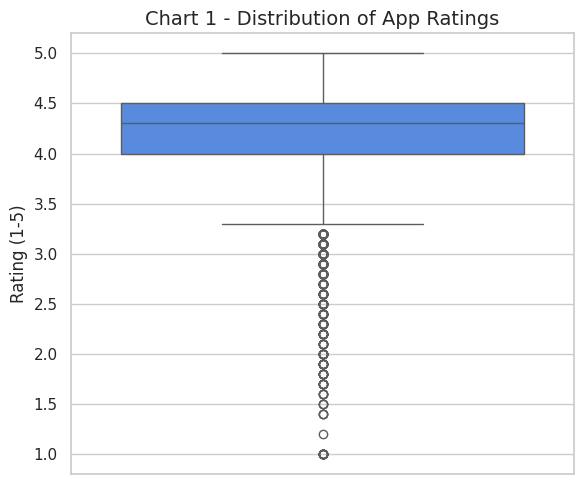


Bottom 5 Outliers — Rating:
                                             App  Rating
                                  CJ DVD Rentals     1.0
                                   CB Mobile Biz     1.0
Lottery Ticket Checker - Florida Results & Lotto     1.0
                                  DS Creator 2.0     1.0
                  FE Mechanical Engineering Prep     1.0


In [5]:
# Rating outliers detection
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, y='Rating', color=GOOGLE_BLUE)
plt.title('Chart 1 - Distribution of App Ratings', fontsize=14)
plt.ylabel('Rating (1-5)', fontsize=12)
plt.tight_layout()
plt.show()

#Print bottom 5 outliers for Rating
print("\nBottom 5 Outliers — Rating:")
print(df.nsmallest(5, 'Rating')[['App', 'Rating']].to_string(index=False))

Most apps cluster between 4.0 and 4.5, with outliers appearing at the low end near 1.0.

A 5.0 rating is a perfect score, not an outlier since rating operates on a fixed 1–5 scale. The concern is poorly rated apps below 3.0.

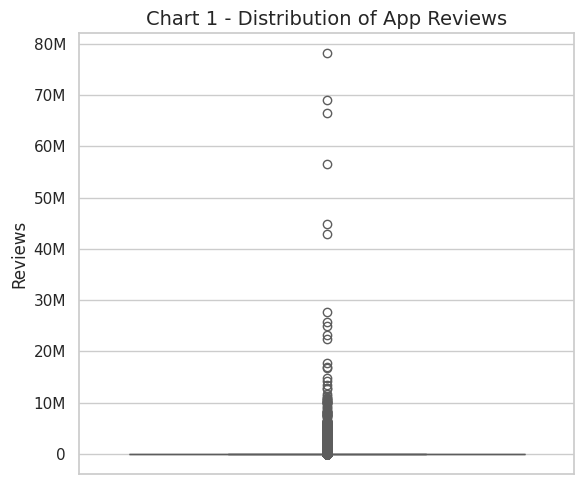

Top 5 Outliers — Reviews:
                                     App  Reviews
                                Facebook 78158306
                      WhatsApp Messenger 69119316
                               Instagram 66577446
Messenger – Text and Video Chat for Free 56646578
                          Clash of Clans 44893888


In [6]:
# Reviews outlier detection
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, y='Reviews', color=GOOGLE_BLUE)
plt.title('Chart 1 - Distribution of App Reviews', fontsize=14)
plt.ylabel('Reviews', fontsize=12)

#Format y-axis labels to show readable numbers
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val/1e6:.0f}M' if val >= 1e6 else f'{val/1e3:.0f}K' if val >= 1e3 else f'{val:.0f}'))
plt.tight_layout()
plt.show()

#Print top 5 outliers for Reviews
print("Top 5 Outliers — Reviews:")
print(df.nlargest(5, 'Reviews')[['App', 'Reviews']].to_string(index=False))

Reviews are heavily right-skewed, with a few apps like Facebook (78M reviews) dominating while the vast majority have below 5M. This reflects a market where user engagement concentrates around a handful of dominant apps.

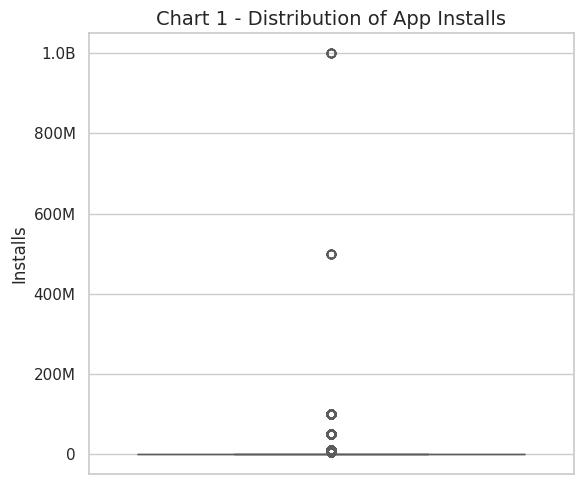


Top 5 Outliers — Installs:
                                     App   Installs
                                Facebook 1000000000
                      WhatsApp Messenger 1000000000
                               Instagram 1000000000
Messenger – Text and Video Chat for Free 1000000000
                          Subway Surfers 1000000000


In [7]:
# Installs outlier detection
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, y='Installs', color=GOOGLE_BLUE)
plt.title('Chart 1 - Distribution of App Installs', fontsize=14)
plt.ylabel('Installs', fontsize=12)
# Format y-axis labels to show readable numbers
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val/1e9:.1f}B' if val >= 1e9 else f'{val/1e6:.0f}M' if val >= 1e6 else f'{val/1e3:.0f}K' if val >= 1e3 else f'{val:.0f}'))
plt.tight_layout()
plt.show()

#Print top outliers for Installs
print("\nTop 5 Outliers — Installs:")
print(df.nlargest(5, 'Installs')[['App', 'Installs']].to_string(index=False))

Installs follow the same extreme skew as Reviews. Most apps are compressed near bottom of the chart, under 1 million installs, while a few reach 1 billion. Note that install counts are bucketed (e.g., 1,000,000+), so top apps show identical values.

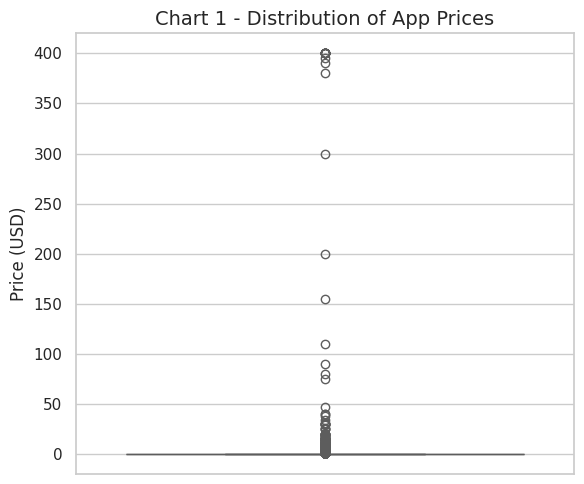


Percentage of free apps: 92.2%

Top 5 Outliers — Price:
                     App  Price
I'm Rich - Trump Edition 400.00
               I am rich 399.99
       I Am Rich Premium 399.99
          I am Rich Plus 399.99
              💎 I'm rich 399.99


In [8]:
# Price outliers detection
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, y='Price', color=GOOGLE_BLUE)
plt.title('Chart 1 - Distribution of App Prices', fontsize=14)
plt.ylabel('Price (USD)', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate percentage of free apps
free_percentage = (df['Price'] == 0).mean() * 100
print(f"\nPercentage of free apps: {free_percentage:.1f}%")

#Print top outliers for Price
print("\nTop 5 Outliers — Price:")
print(df.nlargest(5, 'Price')[['App', 'Price']].to_string(index=False))

The vast majority of apps are free (price = 0). Extreme outliers at `$399-$400` are novelty apps like "I Am Rich," not real commercial products. These may be excluded from pricing-specific analyses in Section 4.3.

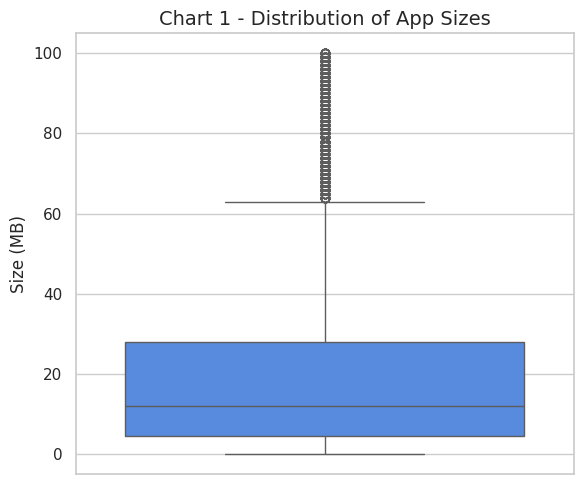


Top 5 Outliers — Size:
                              App  Size
           Hungry Shark Evolution 100.0
                  SimCity BuildIt 100.0
Mini Golf King - Multiplayer Game 100.0
            Miami crime simulator 100.0
                  Ultimate Tennis 100.0


In [9]:
# Size outlier detection
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, y='Size', color=GOOGLE_BLUE)
plt.title('Chart 1 - Distribution of App Sizes', fontsize=14)
plt.ylabel('Size (MB)', fontsize=12)
plt.tight_layout()
plt.show()

#Print top outliers for Size
print("\nTop 5 Outliers — Size:")
print(df.nlargest(5, 'Size')[['App', 'Size']].to_string(index=False))

Most apps are well under 50MB with a median size of about 12MB. A small number of larger apps reach the 100MB maximum recorded in the dataset. Larger apps may face download barriers on devices with limited storage.

#### Section 4.1. Data Quality & Outlier Analysis — Takeaway:

All outliers are kept in the dataset because they represent real apps in the market, not data errors. The heavy skew in Reviews and Installs confirms the winner-take-all nature of the app market, where a small number of apps capture the vast majority of user engagement. For pricing-specific analyses in Section 4.3, extreme novelty apps priced at `$399`–`$400` may be excluded to avoid skewing averages. The impact of other outliers will be addressed on a case-by-case basis in the sections that follow.

###4. 2. What Drives App Success?

This section identifies which measurable factors most strongly influence an app's installs on the Google Play Store. We first define how to measure success, then systematically screen every available factor, quantify each one's real-world impact, and test whether combining multiple factors produces compounding results.

In [10]:
# Create additional columns needed for Section 4.2 analysis

# How many days before the snapshot date was the app last updated?
snapshot = pd.Timestamp("2018-08-08")
df["Days_Since_Update"] = (snapshot - df["Last Updated"]).dt.days

# Minimum Android version, e.g. "4.0.3 and up" becomes 4.0
df["Min_Android"] = df["Android Ver"].str.extract(r"^(\d+\.\d+)")
df["Min_Android"] = pd.to_numeric(df["Min_Android"], errors="coerce")

# How many genres does the app list? e.g. "Art & Design;Creativity" = 2
df["Genre_Count"] = df["Genres"].str.count(";") + 1

#### Chart 2: Correlation Between Key App Metrics

Before analyzing what drives success, we need to define what success means. This heatmap examines the relationships between five key metrics to determine which ones measure the same thing and which are independent. We use Spearman rank correlation rather than Pearson, because all five variables are heavily skewed and Pearson assumes approximate normality.

In [11]:
# Skew above 1 means the data is lopsided, so Pearson would be misleading.
five = ["Rating", "Reviews", "Installs", "Price", "Size"]
print("Skewness of each column:")
print(df[five].skew().round(2))

Skewness of each column:
Rating      -1.75
Reviews     26.57
Installs    15.03
Price       22.53
Size         1.65
dtype: float64


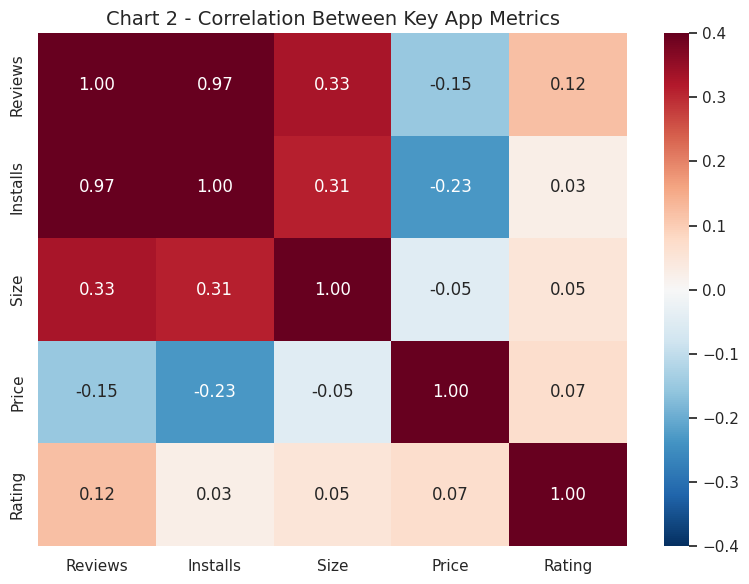

In [12]:
# Chart 2: Correlation Between Key App Metrics
# Order matters: putting Rating last makes it the bottom row of the chart
order = ["Reviews", "Installs", "Size", "Price", "Rating"]
corr = df[order].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-0.4, vmax=0.4)
plt.title("Chart 2 - Correlation Between Key App Metrics", fontsize=14)
plt.tight_layout()
plt.show()

**Correlation Between Key App Metrics (Chart 2)**

**Insight:** Reviews and Installs correlate at 0.97, meaning they can both be used to measure market reach. This allows us to use Installs as the single measure of success and drop Reviews as redundant. Meanwhile, Rating correlates with Installs at just 0.03, proving that user satisfaction and download volume has almost no relationship. An app can be highly rated but rarely downloaded, or massively popular but poorly rated. App Size shows a positive correlation with both Installs (0.31) and Reviews (0.33), indicating that larger, more feature-rich apps tend to attract higher engagement, while Price exhibits a negative correlation with Installs, suggesting paid apps receive fewer downloads.

**Implication:** App success operates on two almost non-related axes: quality (Rating) and reach (Installs). A high-quality app won't automatically attract downloads. Since Reviews and installs are different measures but are highly correlated, so Reviews was excluded from later models to reduce redundancy. The remaining analysis uses Installs as the primary measure of reach and Rating to evaluate quality tradeoffs where relevant.

#### Chart 3: Factors That Explain App Installs

With Installs confirmed as our target variable, we now measure how much of the variation in installs each available factor explains on its own. R-squared tells us the percentage of installs variation attributable to each factor. Installs are log-transformed first because they span nine orders of magnitude.

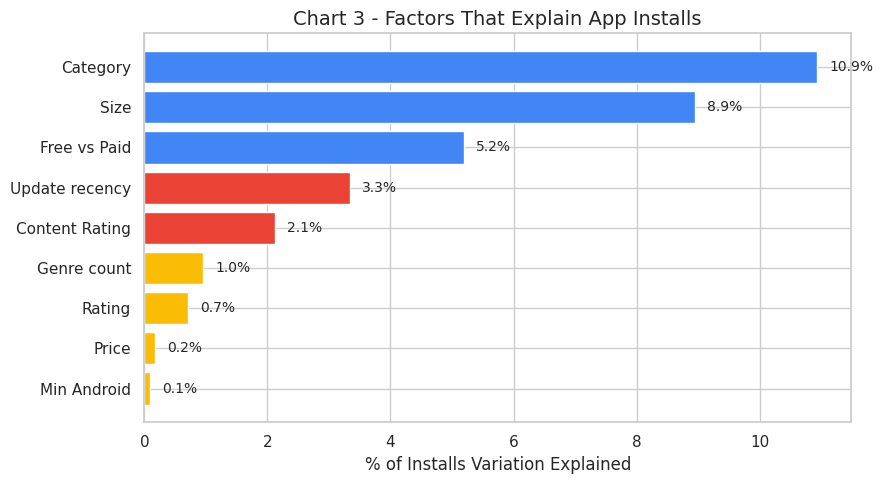

In [13]:
# Chart 3: Factors that Explain App Installs
# Keep apps with at least one install, then take log10 of the install count
apps = df[df["Installs"] > 0].copy()
apps["Log_Installs"] = np.log10(apps["Installs"])

# Function to calculate R-squared for numeric variables
def explained_by_number(column):
    valid = apps.dropna(subset=[column])
    r = valid[column].corr(valid["Log_Installs"])
    return r ** 2 * 100

# Function to calculate R-squared for categorical variables
def explained_by_group(column):
    valid = apps.dropna(subset=[column])
    actual = valid["Log_Installs"]
    group_guess = valid.groupby(column)["Log_Installs"].transform("mean")
    overall_guess = actual.mean()
    error_with_groups = ((actual - group_guess) ** 2).sum()
    error_without = ((actual - overall_guess) ** 2).sum()
    return (1 - error_with_groups / error_without) * 100

# Calculate R-squared for all nine available factors
scores = pd.Series({
    "Category":       explained_by_group("Category"),
    "Size":           explained_by_number("Size"),
    "Free vs Paid":   explained_by_group("Type"),
    "Update recency": explained_by_number("Days_Since_Update"),
    "Content Rating": explained_by_group("Content Rating"),
    "Genre count":    explained_by_number("Genre_Count"),
    "Rating":         explained_by_number("Rating"),
    "Price":          explained_by_number("Price"),
    "Min Android":    explained_by_number("Min_Android"),
}).sort_values(ascending=True)

# Colour by tier so the groups are obvious: blue is strong, red is moderate, yellow is weak
colours = []
for value in scores:
    if value > 5:
        colours.append(GOOGLE_BLUE)
    elif value > 2:
        colours.append(GOOGLE_RED)
    else:
        colours.append("#FBBC05")

# Horizontal bar chart showing each factor's explanatory power
plt.figure(figsize=(9, 5))
bars = plt.barh(scores.index, scores.values, color=colours)

# Add percentage labels next to each bar
for bar in bars:
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f}%', va='center', fontsize=10)

plt.title("Chart 3 - Factors That Explain App Installs", fontsize=14)
plt.xlabel("% of Installs Variation Explained", fontsize=12)
plt.tight_layout()
plt.show()

#### Combined Explanatory Power

To estimate their combined explanatory power, we use a multiple regression that includes all selected variables simultaneously.

The full model explains approximately 25% of the observed variation in log installs. The remaining variation is not explained by this linear model and may reflect omitted factors, such as marketing, brand recognition, app-store optimization, and distribution.

In [14]:
from sklearn.linear_model import LinearRegression

# Include categorical variables as dummies
dummies = pd.get_dummies(apps[['Category', 'Type', 'Content Rating']], drop_first=True)
numerics = apps[['Size', 'Price', 'Rating', 'Days_Since_Update', 'Min_Android', 'Genre_Count']]

X = pd.concat([numerics, dummies], axis=1).dropna()
y = apps.loc[X.index, 'Log_Installs']

model = LinearRegression().fit(X, y)
print(f"Combined R-squared: {model.score(X, y):.1%}")

Combined R-squared: 25.2%


**Factors That Explain App Installs (Chart 3)**

**Insight:** Category (10.9%), Size (8.9%), and the Free vs. Paid decision (5.2%) are the three strongest explanatory factors of installs. A notable finding is that the binary choice of free vs. paid explains 5.2% of variation, while the exact price point explains just 0.2%. This implies that users respond to whether an app is free, not how much it costs. Rating ranks low at 0.7%, reinforcing that quality alone does not drive downloads.

**Implication:** Structural positioning matters more than product quality for exlplaining downloads. Choosing the right category, optimizing app size, and launching as free are higher-impact decisions than perfecting the user experience. However, all measurable factors combined explain about 25% of installs, meaning the remaining 75% depends on external factors like marketing, brand recognition, and promotion not captured in this dataset.

#### Chart 4: Business Impact and Compounding Effect of Success Factors

Chart 2 and 3 above identified the key factors individually. This chart (chart 4) first quantifies the real-world impact of each factor by comparing median installs for apps that meet each condition versus those that do not, then tests whether combining multiple factors produces compounding results.

To quantify real-world impact, we convert the top factors from chart 3 'Factors that Explain App Installs' into binary conditions and compare median installs for apps that meet each condition versus those that do not. Content Rating is explored separately in Section 4.4, and Price is captured by the Free vs. Paid split.

Total high-potential categories: 20
Examples: ['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'COMICS', 'COMMUNICATION', 'EDUCATION', 'ENTERTAINMENT', 'FOOD_AND_DRINK', 'GAME']


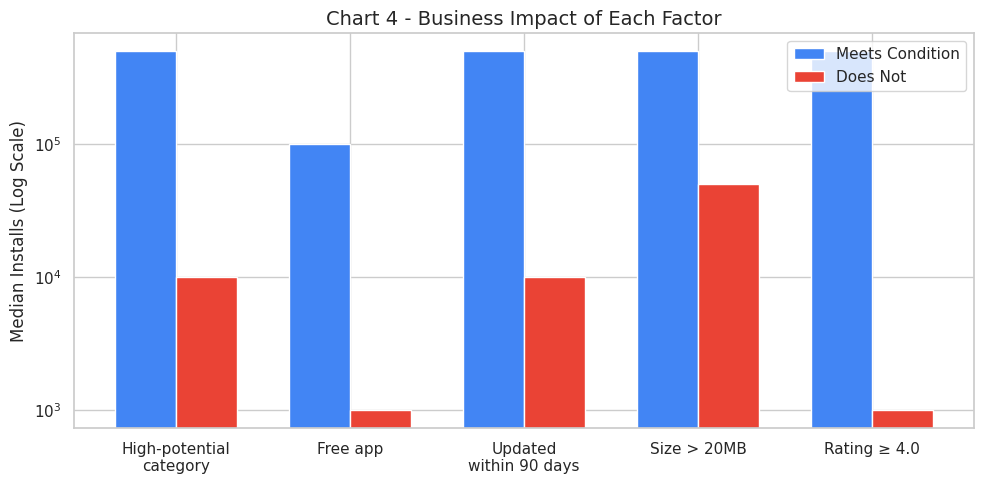

In [15]:
# Chart 4: Business Impact and Compounding Effect of Success Factors
# Identify high-potential categories (median installs >= 100,000)
medians = apps.groupby("Category")["Installs"].median()
top_categories = medians[medians >= 100000].index

print("Total high-potential categories:", len(top_categories))
print("Examples:", list(top_categories[:8]))

# 1. Define a simple function to compare two groups
def get_multiple(condition, data):
    # Filter rows that meet the condition (Yes group)
    yes_group = data[condition]
    # Filter rows that do NOT meet the condition (No group)
    no_group = data[~condition]
    # Calculate the median installs for both groups
    yes_median = yes_group["Installs"].median()
    no_median = no_group["Installs"].median()
    # Return how many times larger the 'Yes' group is
    return yes_median, no_median, yes_median / no_median if no_median > 0 else np.nan

# Define conditions for each factor
conditions = {
    "High-potential\ncategory": apps["Category"].isin(top_categories),
    "Free app":               apps["Price"] == 0,
    "Updated\nwithin 90 days": apps["Days_Since_Update"] <= 90,
    "Size > 20MB":            apps["Size"] > 20,
    "Rating ≥ 4.0":           apps["Rating"] >= 4.0,
}

# Compare median installs: apps that meet each condition vs. those that don't
effect = pd.DataFrame([
    {"factor": name,
     "yes": get_multiple(cond, apps)[0],
     "no":  get_multiple(cond, apps)[1]}
    for name, cond in conditions.items()
])

# Grouped bar chart comparing each factor's real-world impact
x = np.arange(len(effect))
width = 0.35

plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - width/2, effect["yes"], width, label="Meets Condition", color=GOOGLE_BLUE)
bars2 = plt.bar(x + width/2, effect["no"], width, label="Does Not", color=GOOGLE_RED)

# Log scale to show the large gaps between groups
plt.yscale("log")
plt.xticks(x, effect["factor"])
plt.ylabel("Median Installs (Log Scale)", fontsize=12)
plt.title("Chart 4 - Business Impact of Each Factor", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

For the compounding analysis, we focus on the three factors that are both strong drivers and controllable strategic decisions: category choice, free vs. paid pricing, and update recency. Size ranks second in explanatory power (8.9%) but is a product constraint rather than a strategic lever.

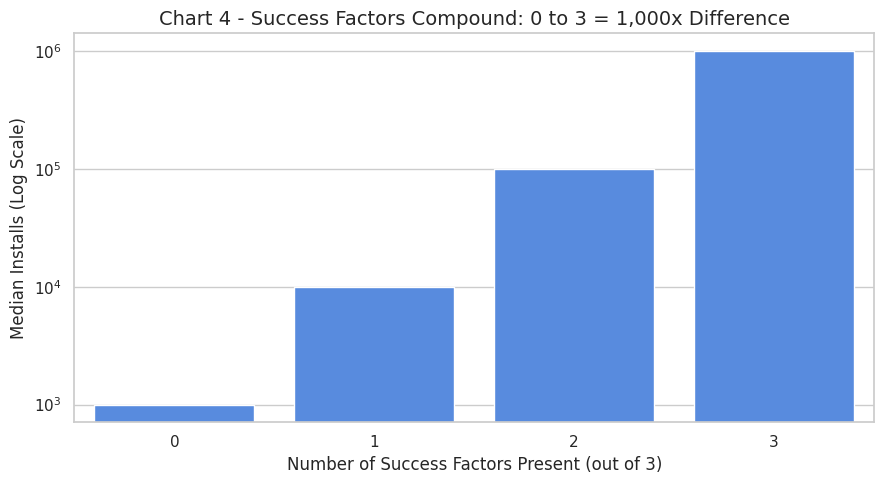


Median installs by number of factors:
       median_installs  app_count
score                            
0               1000.0        364
1              10000.0       2966
2             100000.0       4053
3            1000000.0       2261


In [16]:
# Chart 4b: compounding effect
# Do these factors reinforce each other, or are they all describing the same thing?
# We give every app a score from 0 to 3 on the three strongest controllable factors

# Score each app 0-3 based on three key factors
point1 = apps["Category"].isin(top_categories).astype(int)  # Right category
point2 = (apps["Price"] == 0).astype(int)                    # Free pricing
point3 = (apps["Days_Since_Update"] <= 90).astype(int)       # Recent updates
apps["score"] = point1 + point2 + point3

# Calculate median installs and app count for each score level
recipe = apps.groupby("score")["Installs"].agg(["median", "count"])
recipe.columns = ["median_installs", "app_count"]

# Bar chart showing how factors compound
plt.figure(figsize=(9, 5))
sns.barplot(x=recipe.index, y=recipe["median_installs"], color=GOOGLE_BLUE)

# Log scale to show the 1,000x difference
plt.yscale("log")
plt.xlabel("Number of Success Factors Present (out of 3)", fontsize=12)
plt.ylabel("Median Installs (Log Scale)", fontsize=12)
plt.title("Chart 4 - Success Factors Compound: 0 to 3 = 1,000x Difference", fontsize=14)
plt.tight_layout()
plt.show()

# Print the data behind the chart
print("\nMedian installs by number of factors:")
print(recipe.to_string())

**Business Impact and Compounding Effect of Success Factors (Chart 4)**

**Insight:** Free apps have 100 times the median installs of paid apps - 100,000 compared with 1,000. High-potential categories and apps updated within 90 days each show approximately 50 times higher median installs than their comparison groups. However, the rating comparison in the current chart should be rechecked before ranking the factors by impact. When the three selected conditions - high-potential category, free pricing, and an update within 90 days - are considered together, median installs rise from approximately 1,000 for apps meeting none of the conditions to 1,000,000 for apps meeting all three, a 1,000-fold observed difference. This pattern shows a strong association but does not prove that adding each condition causes the increase.

**Implication:** No single condition guarantees success. Apps meeting more of the three conditions tend to have substantially higher median installs. The strongest observed launch position combines a favorable category, free pricing, and recent maintenance, although other factors not captured in the dataset also influence performance.

#### Section 4.2. What Drives App Success — Takeaway:

App success operates on two independent dimensions: product quality (Rating) and market reach (Installs). Since these are uncorrelated, a high-quality app will not automatically attract downloads. The strongest drivers of reach are category choice, app size, and the decision to launch free. These factors matter but not the whole story. They explain about 25% of why some apps get more downloads than others. The remaining 75% depend on things like marketing and brand recognition that are not captured in this dataset. Most importantly, these factors compound, meaning apps that combine the right category, free pricing, and recent updates, achieve 1,000x more installs than those with none. This finding directly informs the pricing analysis in Section 4.3 and the market positioning analysis in Section 4.4.

### 4.3. Pricing Strategy
This section answers a three-part pricing question: which app categories can support paid pricing model, whether going paid actually outperforms staying free in those categories, and what specific price point maximizes market outcome, given that paid works in this category. Each chart narrows the funnel further, moving from broad market overview to a specific pricing recommendation.

#### Chart 5: Which Categories Support Paid Pricing?

Before recommending a pricing strategy, we first identify which categories have meaningful adoption of paid apps. A category with very few paid apps signals that users in that market are unwilling to pay.

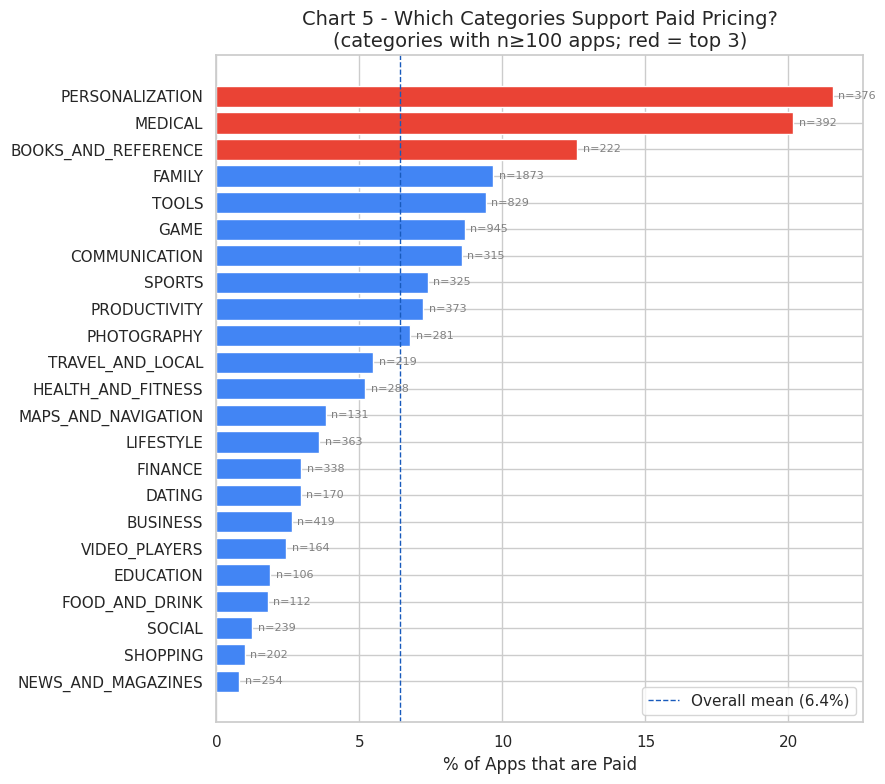

In [17]:
# Chart 5: Which Categories Support Paid Pricing?

# Filter out novelty apps priced above $50 (e.g., "I Am Rich")
# These are not real commercial products and would distort pricing analysis
df_pricing = df[df['Price'] <= 50].copy()

# Calculate paid-app share for each category
grp = df_pricing.groupby('Category').agg(
    n_total=('App', 'count'),
    n_paid=('Type', lambda x: (x == 'Paid').sum())
)
grp['pct_paid'] = grp['n_paid'] / grp['n_total'] * 100

# Keep only categories with at least 100 apps for reliable results
grp = grp[grp['n_total'] >= 100].sort_values('pct_paid', ascending=True)

# Highlight the top 3 categories in red, rest in blue
colors = [GOOGLE_RED if cat in ['PERSONALIZATION', 'MEDICAL', 'BOOKS_AND_REFERENCE']
          else GOOGLE_BLUE for cat in grp.index]

plt.figure(figsize=(9, 8))
plt.barh(grp.index, grp['pct_paid'], color=colors)
plt.xlabel('% of Apps that are Paid', fontsize=12)
plt.title('Chart 5 - Which Categories Support Paid Pricing?\n(categories with n≥100 apps; red = top 3)', fontsize=14)

# Add overall mean as reference line
plt.axvline(grp['pct_paid'].mean(), color='#185ABC', linestyle='--', linewidth=1,
            label=f"Overall mean ({grp['pct_paid'].mean():.1f}%)")

# Annotate each bar with sample size
for i, (cat, row) in enumerate(grp.iterrows()):
    plt.text(row['pct_paid'] + 0.2, i, f"n={row['n_total']:.0f}",
             va='center', fontsize=8, color='gray')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Categories That Support Paid Pricing (Chart 5)**

**Insight:** The prevalence of paid apps drops sharply after the leading categories. Personalization and Medical form a clear top tier, with approximately 20–22% of apps listed as paid. Books & Reference ranks third at about 13%, roughly 8–9 percentage points below Personalization and Medical. The remaining 20 categories are all in the single digits.

Game ranks sixth despite being one of the larger categories in the dataset. This may partly reflect the chart’s focus on upfront prices, since it does not capture revenue generated through in-app purchases or other monetization methods.

**Implication:** Only a small number of categories show a relatively high prevalence of upfront paid pricing. Personalization, Medical, and Books & Reference are therefore selected for comparison in Chart 6. Based on those results, Chart 7 focuses specifically on Personalization to evaluate the relationship between price, downloads, and estimated revenue.

Apps priced above $50 were excluded because they were treated as extreme outliers rather than representative market offerings, consistent with the findings in Section 4.1.

#### Chart 6: Does Paid Outperform Free in Categories That Support Paid?

The previous chart identified which categories tolerate paid pricing. This chart tests whether paid apps in those categories actually perform better than free ones, examining both quality (Rating) and reach (Installs).

=== Rating & Installs: Free vs Paid ===
PERSONALIZATION: Free rating median=4.30, Paid rating median=4.40, Free installs median=100,000, Paid installs median=500
MEDICAL: Free rating median=4.30, Paid rating median=4.40, Free installs median=1,000, Paid installs median=1,000
BOOKS_AND_REFERENCE: Free rating median=4.50, Paid rating median=4.45, Free installs median=50,000, Paid installs median=10


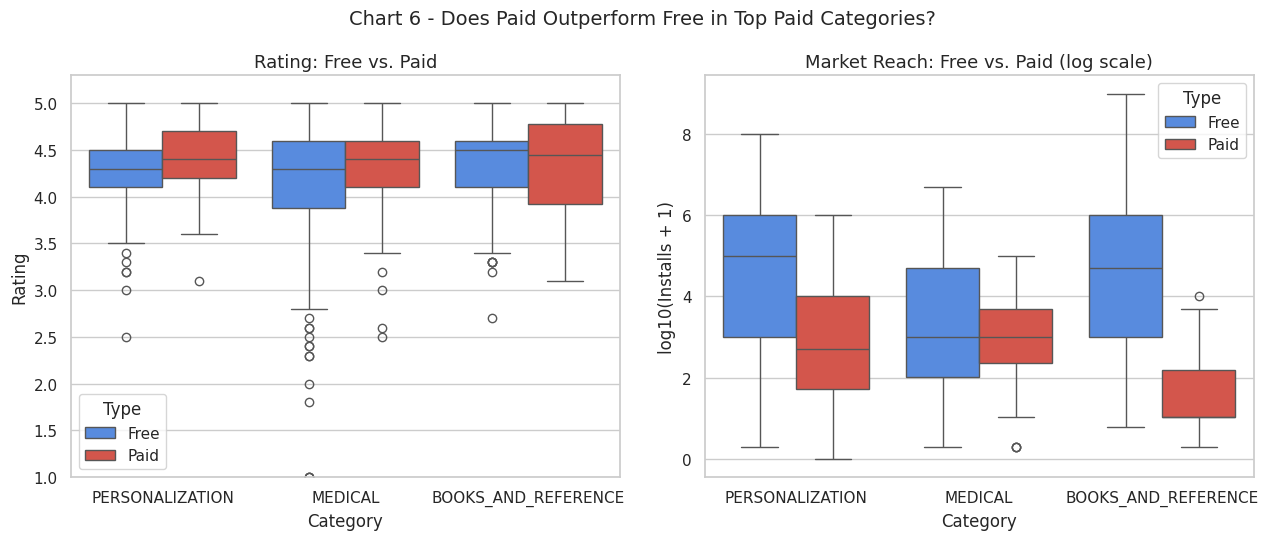

In [18]:
#Chart 6: Does Paid Outperform Free in Categories That Support Paid?

# Filter to the top 3 paid-market categories identified in Chart 5
top_cats = ['PERSONALIZATION', 'MEDICAL', 'BOOKS_AND_REFERENCE']
sub = df_pricing[df_pricing['Category'].isin(top_cats)].copy()

# Log-transform Installs for readable boxplots (installs span many orders of magnitude)
sub['log_Installs'] = np.log10(sub['Installs'] + 1)

# Print median comparison for reference
print("=== Rating & Installs: Free vs Paid ===")
for cat in top_cats:
    cat_df = sub[sub['Category'] == cat]
    free_r = cat_df[cat_df['Type'] == 'Free']['Rating'].dropna()
    paid_r = cat_df[cat_df['Type'] == 'Paid']['Rating'].dropna()
    free_i = cat_df[cat_df['Type'] == 'Free']['Installs'].median()
    paid_i = cat_df[cat_df['Type'] == 'Paid']['Installs'].median()
    print(f"{cat}: Free rating median={free_r.median():.2f}, Paid rating median={paid_r.median():.2f}, "
          f"Free installs median={free_i:,.0f}, Paid installs median={paid_i:,.0f}")

# Side-by-side boxplots: Rating (left) and Installs (right)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left panel — Quality (Rating)
sns.boxplot(data=sub, x='Category', y='Rating', hue='Type', ax=axes[0],
            palette={'Free': GOOGLE_BLUE, 'Paid': GOOGLE_RED}, order=top_cats)
axes[0].set_title('Rating: Free vs. Paid', fontsize=13)
axes[0].set_xlabel('Category', fontsize=12)
axes[0].set_ylabel('Rating', fontsize=12)
axes[0].set_ylim(1, 5.3)

# Right panel — Reach (log Installs)
sns.boxplot(data=sub, x='Category', y='log_Installs', hue='Type', ax=axes[1],
            palette={'Free': GOOGLE_BLUE, 'Paid': GOOGLE_RED}, order=top_cats)
axes[1].set_title('Market Reach: Free vs. Paid (log scale)', fontsize=13)
axes[1].set_xlabel('Category', fontsize=12)
axes[1].set_ylabel('log10(Installs + 1)', fontsize=12)

fig.suptitle('Chart 6 - Does Paid Outperform Free in Top Paid Categories?', fontsize=14)
plt.tight_layout()
plt.show()

**Does Paid Outperform Free in Top Paid Categories? (Chart 6)**

**Insight:** Paid apps do not consistently outperform free apps. Paid apps have slightly higher median ratings in Personalization and Medical, by about 0.10 rating points, while free apps have a slightly higher median rating in Books & Reference. These differences are small and should not be considered statistically meaningful without further testing.

Free apps achieve substantially greater median installs in Personalization and Books & Reference. In Personalization, free apps have approximately 200 times the median installs of paid apps, while in Books & Reference they have about 5,000 times more. In Medical, free and paid apps have the same median number of installs.

**Implication:** Personalization presents the strongest relative case for paid pricing because it combines evidence of market willingness to pay from Chart 5 with a small median rating advantage for paid apps. Medical provides limited evidence either for or against a paid model, as paid apps have a slightly higher rating but no difference in median reach. Books & Reference provides the weakest case, since paid apps have substantially lower reach without a rating advantage. Chart 7 therefore focuses on Personalization to examine which price point offers the best balance between reach and estimated revenue.

#### Chart 7: What Price Point Maximizes Market Outcome?

With Personalization confirmed as the only category where paid pricing could be justified, this chart examines which specific price tier delivers the best balance of downloads and estimated revenue.

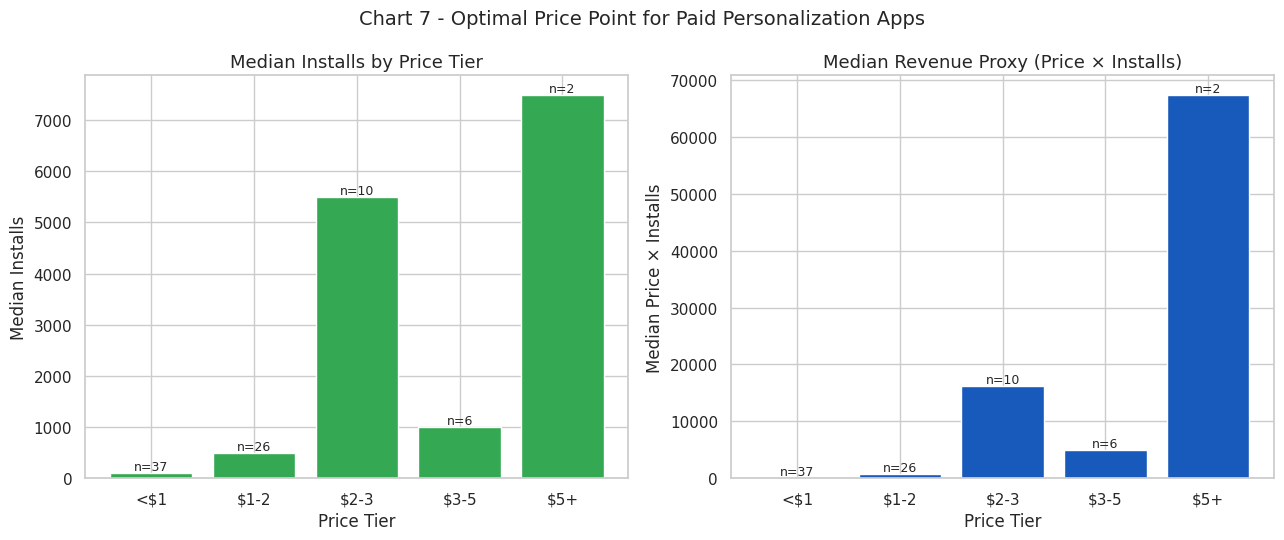


Price tier summary:
             n  median_installs  median_revenue_proxy
price_tier                                           
<$1         37            100.0                  99.0
$1-2        26            500.0                 745.0
$2-3        10           5500.0               16195.0
$3-5         6           1000.0                4990.0
$5+          2           7500.0               67425.0


In [19]:
# Chart 7: What Price Point Maximizes Market Outcome?
# Keep only paid Personalization apps (the only category that passed Charts 5 and 6)
paid = df_pricing[(df_pricing['Category'] == 'PERSONALIZATION') & (df_pricing['Type'] == 'Paid')].copy()

# Create a revenue proxy: Price × Installs (simplified estimate)
paid['revenue_proxy'] = paid['Price'] * paid['Installs']

# Bucket prices into tiers
bins = [0, 1, 2, 3, 5, 100]
labels = ['<$1', '$1-2', '$2-3', '$3-5', '$5+']
paid['price_tier'] = pd.cut(paid['Price'], bins=bins, labels=labels, right=False)

# Calculate median metrics and sample size per tier
summary = paid.groupby('price_tier', observed=True).agg(
    n=('App', 'count'),
    median_installs=('Installs', 'median'),
    median_revenue_proxy=('revenue_proxy', 'median'),
).reindex(labels)

# Two colors to distinguish reach vs. revenue
GOOGLE_GREEN = '#34A853'
GOOGLE_DARK_BLUE = '#185ABC'

# Side-by-side panels: Installs (left) and Revenue Proxy (right)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left panel — Reach (Installs)
axes[0].bar(summary.index, summary['median_installs'], color=GOOGLE_GREEN)
axes[0].set_title('Median Installs by Price Tier', fontsize=13)
axes[0].set_ylabel('Median Installs', fontsize=12)
axes[0].set_xlabel('Price Tier', fontsize=12)
# Annotate sample sizes
for i, (tier, row) in enumerate(summary.iterrows()):
    axes[0].text(i, row['median_installs'], f"n={row['n']:.0f}",
                 ha='center', va='bottom', fontsize=9)

# Right panel — Revenue Proxy
axes[1].bar(summary.index, summary['median_revenue_proxy'], color=GOOGLE_DARK_BLUE)
axes[1].set_title('Median Revenue Proxy (Price × Installs)', fontsize=13)
axes[1].set_ylabel('Median Price × Installs', fontsize=12)
axes[1].set_xlabel('Price Tier', fontsize=12)
for i, (tier, row) in enumerate(summary.iterrows()):
    axes[1].text(i, row['median_revenue_proxy'], f"n={row['n']:.0f}",
                 ha='center', va='bottom', fontsize=9)

fig.suptitle('Chart 7 - Optimal Price Point for Paid Personalization Apps', fontsize=14)
plt.tight_layout()
plt.show()

# Print summary table for reference
print("\nPrice tier summary:")
print(summary.to_string())

**Optimal Price Point for Paid Personalization Apps (Chart 7)**

**Insight:** The `$2–3` price tier outperforms all others, surging in both median installs and revenue proxy compared to cheaper tiers. Apps priced below `$2`, which make up the majority of paid Personalization apps, actually underperform. This demonstrates that the lowest price does not guarantee the highest volume. The `$5+` tier shows high revenue proxy but is based on only 2 apps, making it unreliable.

**Implication:** For a new paid Personalization app, the `$2–3` range represents the best-supported price point in the data. However, this finding comes with important caveats: the sample size at `$2–3` is only 10 apps, the revenue proxy is a simplification, and this recommendation applies only to Personalization as Chart 5 and 6 show that other categories lack sufficient evidence to justify paid pricing at all.

#### Section 4.3. Pricing Strategy - Takeaway

The pricing analysis follows a three-step funnel. First, Personalization, Medical, and Books & Reference emerge as the categories with the highest relative adoption of paid pricing. Second, Personalization provides the strongest case for a paid model, showing a small but consistent rating advantage for paid apps alongside evidence of market willingness to pay. Third, within Personalization, the `$2–3` price tier appears to offer the best balance between downloads and estimated revenue.

The broader conclusion is that free pricing remains the dominant strategy across most categories. Paid pricing may succeed in selected markets where users have demonstrated a willingness to pay, but the price point must be carefully calibrated. This is consistent with Section 4.2, where the free-versus-paid distinction explains 5.2% of the variation in installs. This is a measurable influence, although most variation is driven by other factors.

### 4. 4. Market & Audience Positioning

This section identifies which categories and audience segments offer the strongest opportunity for a new app launch by examining installs across content ratings, category performance, and market momentum.

#### Chart 8: Median Installs by Target Audience

This chart explores how an app's target audience affects its download potential, comparing median installs across content rating segments from "Everyone" to "Adults only 18+."

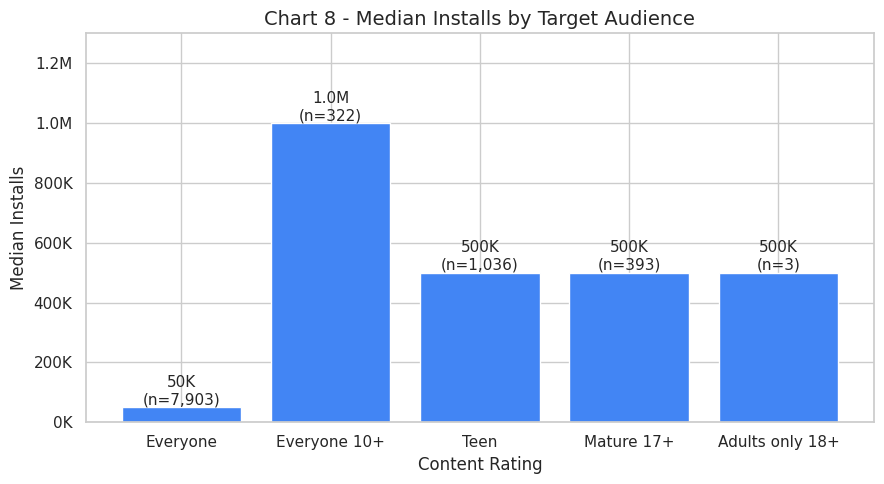

In [20]:
# Chart 8 - Median Installs by Content Rating
# Calculate median installs by content rating
order = ['Everyone', 'Everyone 10+', 'Teen', 'Mature 17+', 'Adults only 18+']
median_installs = df.groupby('Content Rating')['Installs'].median().reindex(order)
app_counts = df.groupby('Content Rating')['Installs'].count().reindex(order)

# Create bar chart
plt.figure(figsize=(9, 5))
bars = plt.bar(median_installs.index, median_installs.values, color=GOOGLE_BLUE)

# Add median value + n-count on top of each bar
for bar, n in zip(bars, app_counts.values):
    height = bar.get_height()
    if height >= 1e6:
        label = f'{height/1e6:.1f}M'
    elif height >= 1e3:
        label = f'{height/1e3:.0f}K'
    else:
        label = f'{height:.0f}'
    label += f'\n(n={n:,})'
    plt.text(bar.get_x() + bar.get_width()/2, height, label,
             ha='center', va='bottom', fontsize=11)

# Add title and labels
plt.title('Chart 8 - Median Installs by Target Audience', fontsize=14)
plt.xlabel('Content Rating', fontsize=12)
plt.ylabel('Median Installs', fontsize=12)
# Format y-axis labels to show readable numbers
from matplotlib.ticker import FuncFormatter
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val/1e6:.1f}M' if val >= 1e6 else f'{val/1e3:.0f}K'))
plt.ylim(0, median_installs.max() * 1.3)
plt.tight_layout()
plt.show()

**Note:** Install counts in this dataset are bucketed (e.g., 1,000,000+), not exact figures. Apps at the top of each content rating group may show identical values because the dataset records the bucket floor, not the precise download count.

**Median Installs by Target Audience (Chart 8)**

**Insight:** Apps rated “Everyone 10+” have the highest observed median installs at 1.0 million. Teen and Mature 17+ apps both have median installs of 500,000, while Everyone-rated apps have a lower median of 50,000. The Adults only 18+ category also records a median of 500,000, but its very small sample size makes meaningful comparison difficult.

The lower median among Everyone-rated apps indicates that at least half of the apps in this large category have 50,000 installs or fewer. However, the chart alone does not explain why this pattern occurs.

**Implication:** A broader content rating is not necessarily associated with higher median installs. Content rating may be one factor related to market reach, but it should be assessed alongside category, competition, ratings, pricing, and other app characteristics. Chart 10 can examine whether the pattern remains after considering category differences.

#### Chart 9: Top 10 Categories - App Quality vs. Popularity

This chart examines whether categories with high download volumes also maintain high user satisfaction, or whether popularity comes at the cost of quality.

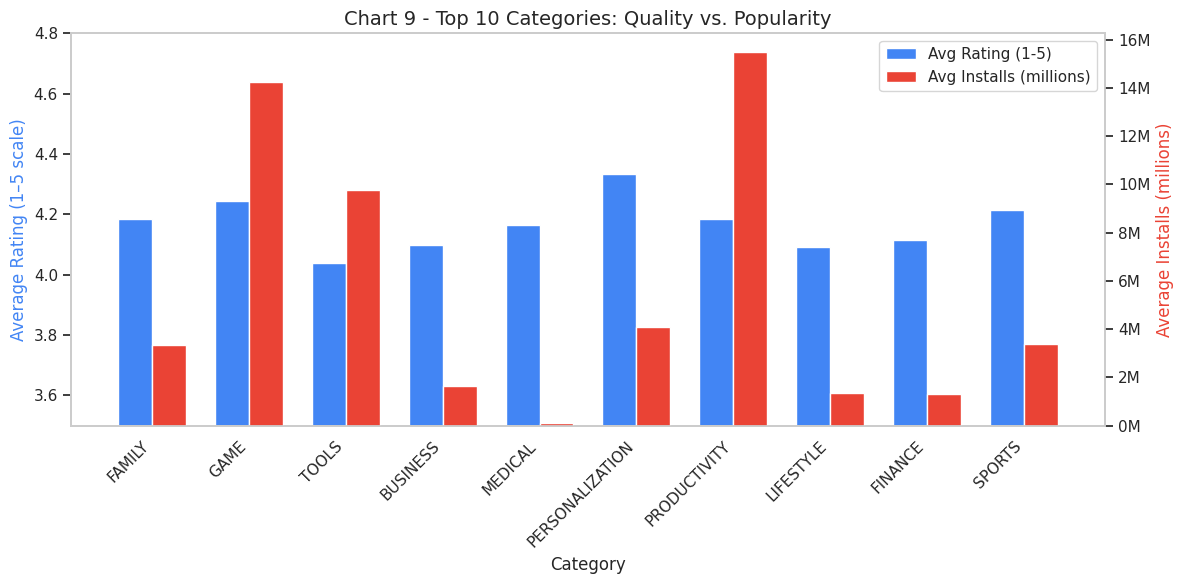

In [21]:
# Chart 9 - Top 10 app categories: Average Rating vs. Average Installs
import numpy as np
from matplotlib.ticker import FuncFormatter

# Get the top 10 categories by number of apps
top10 = df['Category'].value_counts().head(10).index

# Filter dataset to only include top 10 categories
df_top10 = df[df['Category'].isin(top10)]

# Calculate average rating and average installs for each category
avg_data = df_top10.groupby('Category').agg(
    Avg_Rating=('Rating', 'mean'),
    Avg_Installs=('Installs', 'mean')
).loc[top10]

# Set up x-axis positions and bar width for grouped bars
x = np.arange(len(avg_data))
width = 0.35

# Create figure
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot average rating bars on the left y-axis (blue)
ax1.bar(x - width/2, avg_data['Avg_Rating'], width, color=GOOGLE_BLUE, label='Avg Rating (1-5)')
ax1.set_ylabel('Average Rating (1–5 scale)', fontsize=12, color=GOOGLE_BLUE)
ax1.set_ylim(3.5, 4.8)

# Create a second y-axis for installs on the right side (red)
ax2 = ax1.twinx()
ax2.bar(x + width/2, avg_data['Avg_Installs'], width, color=GOOGLE_RED, label='Avg Installs (millions)')
ax2.set_ylabel('Average Installs (millions)', fontsize=12, color=GOOGLE_RED)

# Format right axis to show millions instead of scientific notation
ax2.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val/1e6:.0f}M'))

# Set category names on x-axis, rotated for readability
ax1.set_xticks(x)
ax1.set_xticklabels(avg_data.index, rotation=45, ha='right')
ax1.set_xlabel('Category', fontsize=12)

# Add title
plt.title('Chart 9 - Top 10 Categories: Quality vs. Popularity', fontsize=14)

# Combine legends from both axes into one
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.grid(False)
ax2.grid(False)
plt.tight_layout()
plt.show()

**Top 10 Categories: Quality vs. Popularity (Chart 9)**

**Insight**: The chart shows that app quality and popularity do not necessarily move together. **Productivity** and **Game** record the highest average installs, but they are not the highest-rated categories. In contrast, **Personalization** has one of the highest average ratings while achieving more moderate install levels. This suggests that strong user ratings do not always translate into broad market reach.

**Implication**: App success should be defined according to the strategic objective, maximizing downloads, achieving high user satisfaction, or balancing both. **Tools**, for example, combines relatively high average installs with comparatively lower ratings, which may indicate an opportunity for a better-rated product. However, this potential should be validated through user reviews, competitor analysis, and evidence of unmet needs before concluding that a clear market gap exists.

####Chart 10: Installs by Category and Content Rating

This chart examines how installs vary across the intersection of category and target audience, revealing which combinations drive the most downloads.

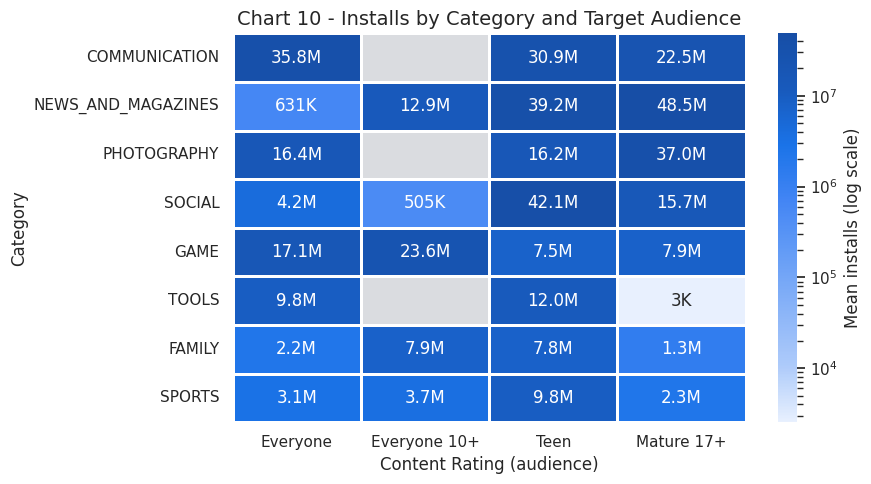

In [22]:
# Chart 10 — filter to main content ratings
from matplotlib.colors import LinearSegmentedColormap, LogNorm

MAIN_RATINGS = ["Everyone", "Everyone 10+", "Teen", "Mature 17+"]
df_chart10 = df[df["Content Rating"].isin(MAIN_RATINGS)].copy()
df_chart10["Content Rating"] = pd.Categorical(df_chart10["Content Rating"], categories=MAIN_RATINGS, ordered=True)

# Sequence blue for heatmap gradient
SEQ_BLUE = ["#E8F0FE", "#AECBFA", "#8AB4F8", "#669DF6",
            "#4285F4", "#1A73E8", "#185ABC", "#174EA6"]

# Start from the top 15 categories by app count, then keep the 8 with the
# highest average installs
top15 = df_chart10["Category"].value_counts().head(15).index
pivot = (df_chart10[df_chart10["Category"].isin(top15)]
         .pivot_table(index="Category", columns="Content Rating",
                      values="Installs", aggfunc="mean", observed=True))
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).head(8).index]

# Label cells as 38.5M / 631K so small cells don't print a misleading "0.0M"
fmt = lambda v: ("" if pd.isna(v) else f"{v/1e6:.1f}M" if v >= 1e6
                 else f"{v/1e3:.0f}K" if v >= 1e3 else f"{v:.0f}")

cmap = LinearSegmentedColormap.from_list("gblue", SEQ_BLUE)
cmap.set_bad("#DADCE0")  # grey = no apps exist for that combo (not zero)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=pivot.map(fmt), fmt="", cmap=cmap,
            # log color scale so 1B-install mega-apps don't wash out other cells
            norm=LogNorm(vmin=pivot.min().min(), vmax=pivot.max().max()),
            linewidths=2, linecolor="white",
            cbar_kws={"label": "Mean installs (log scale)"})
plt.title("Chart 10 - Installs by Category and Target Audience", fontsize=14)
plt.xlabel("Content Rating (audience)", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.tight_layout()
plt.show()

**Installs by Category and Target Audience (Chart 10)**

**Insight**: Mean installs vary substantially across category–audience combinations, and no single content rating performs best in every category. Communication performs strongest among Everyone-rated apps at 35.8M mean installs, while Social performs strongest among Teen-rated apps at 42.1M. Mature 17+ leads in News & Magazines and Photography, whereas Everyone 10+ leads in Game. These patterns indicate that the relationship between target audience and installs depends strongly on app category.


**Implication**: Audience strategy should be evaluated within the intended category rather than assuming that the broadest content rating will generate the greatest reach. Developers should compare category-specific audience patterns, sample sizes, and competitive conditions before selecting a target rating. Because the chart reports mean installs, the results may be influenced by a small number of highly downloaded apps and should be interpreted alongside median installs and group counts.

#### Chart 11: Market Momentum: Most vs. Least Active Categories

This chart evaluates market momentum by measuring how recently apps in each category have been updated, revealing which markets are actively growing versus saturated with abandoned apps.

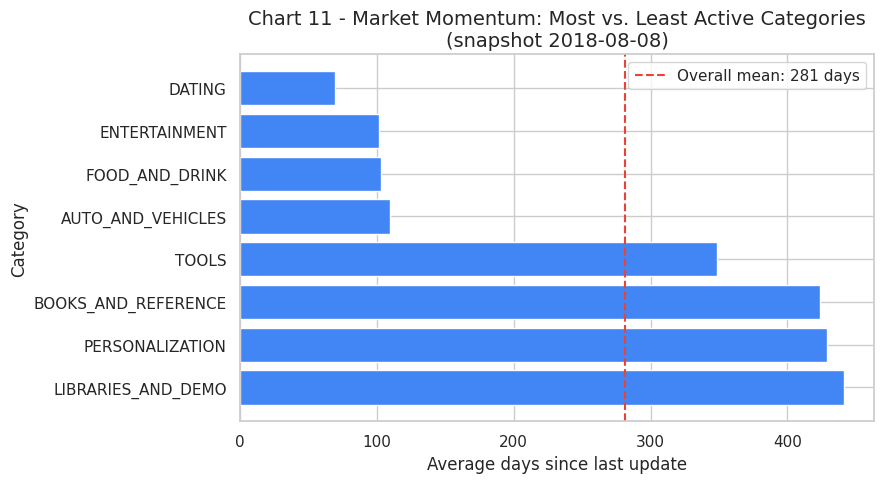

In [23]:
# Chart 11: Average Days Since Last Update by Category
# Business question: which markets are actively maintained vs. abandoned?

# Use the dataset's newest date as the reference point (August 2018 snapshot)
snapshot = df["Last Updated"].max()

# Calculate how many days since each app was last updated
df["days_since_update"] = (snapshot - df["Last Updated"]).dt.days

# Calculate average staleness per category
avg_stale = df.groupby("Category")["days_since_update"].mean().sort_values()

# Calculate overall market average for reference line
overall = df["days_since_update"].mean()

# Show only the 4 freshest and 4 stalest categories (extremes tell the story)
extremes = pd.concat([avg_stale.head(4), avg_stale.tail(4)])

# Horizontal bar chart, freshest at the top
plt.figure(figsize=(9, 5))
plt.barh(extremes.index[::-1], extremes.values[::-1], color=GOOGLE_BLUE)

# Red dashed line showing overall market average
plt.axvline(overall, color=GOOGLE_RED, ls="--",
            label=f"Overall mean: {overall:.0f} days")

# Add title and labels
plt.title(f"Chart 11 - Market Momentum: Most vs. Least Active Categories\n(snapshot {snapshot.date()})", fontsize=14)
plt.xlabel("Average days since last update", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

**Market Momentum: Most vs. Least Active Categories (Chart 11)**

**Insight**: Update recency varies substantially across categories. **Dating** apps had been updated most recently on average, at roughly 70 days since the last update. **Entertainment**, **Food & Drink**, and **Auto & Vehicles** also fell below the overall mean of 281 days. In contrast, **Books & Reference**, **Personalization**, and **Libraries & Demo** averaged more than 400 days since their last update, indicating less recent maintenance within the dataset.

**Implication**: Categories with more recent updates may require a stronger ongoing maintenance strategy to meet current market expectations. Categories with older updates may offer opportunities for a modern, actively maintained product, but update age alone does not establish low competition or unmet demand. Category size, ratings, installs, and recent competitor activity should also be assessed.

####Section 4.4. Market & Audience Positioning — Takeaway

App performance is associated with several factors, including category, target audience, and update recency. “Everyone 10+” records the highest overall median installs, but the best-performing audience varies by category. Communication performs strongest among “Everyone” apps, while “Everyone 10+” leads in Game.

Categories such as Tools combine high downloads with comparatively lower ratings, suggesting a potential quality-improvement opportunity that requires further validation. Update patterns also differ across categories: Dating apps are updated more recently on average, while Libraries & Demo has an older update cycle. However, update recency alone does not prove high competition or easy market entry.

A stronger launch strategy combines a high-demand category, an audience fit supported by category-level data, and an understanding of competitor activity and maintenance expectations.

## 5. Key Insights & Recommendations

###5.1. Key Insights

**What Drives Success**
Rating and installs are only weakly correlated (0.03), indicating that high user satisfaction does not automatically translate into broad market reach. Among the factors tested, category, app size, and the free-versus-paid pricing model have the greatest explanatory power. Apps combining a favorable category, free pricing, and recent update status record approximately 1,000 times higher median installs than apps meeting none of these conditions. Overall, the full regression model explains about 25% of the observed variation in log installs, meaning that most variation remains unexplained by the variables included in the analysis.

**Pricing Strategy**
Free pricing generally provides substantially greater reach. Personalization presents the strongest relative case for testing a paid model because paid apps show a small rating advantage and paid listings are comparatively common in this category. Within Personalization, the `$2–3` price tier performs best among the better-sampled groups, although it should be treated as a price point to test rather than a guaranteed optimum.

**Market and Audience Positioning**
The strongest content rating varies by category. Although “Everyone 10+” has the highest overall median installs, category-level results show that no single audience strategy works universally. Tools may present a potential quality-improvement opportunity because it combines high installs with comparatively lower ratings. Update recency also differs across categories, suggesting that maintenance expectations should be evaluated within the competitive context of each market.

###5.2. Recommendations
Based on the key findings above, we recommend the following strategies for launching a new app on the Google Play Store:

**Choose the category strategically**. Category has the greatest individual explanatory power among the variables tested. Evaluate category-level installs, ratings, audience patterns, and competition before committing to development.

**Use free pricing as the lower-risk default**. In Personalization, consider testing a paid model, with `$2–3` as the strongest-supported tier among adequately sampled groups. Do not assume this price will be optimal for every Personalization app.

**Target quality gaps**. Categories such as Tools combine strong reach with comparatively lower ratings, which may indicate room for a better-rated product. Validate this opportunity through reviews, competitor research, and evidence of unmet user needs.

**Do not increase app size simply to pursue downloads**. Size is positively associated with installs, but the analysis does not show that larger files cause success or that users prefer feature-heavy apps. Focus on useful functionality while keeping size appropriate for the product.

**Update regularly**. Recent maintenance may support performance and may help differentiate an app in categories with older update cycles. However, competitor activity and demand should be assessed separately.

**Match content rating to category**. Validate the target audience within the intended category rather than automatically selecting the broadest rating.

**Align all three controllable factors**. Apps combining a favorable category, free pricing, and recent update status have substantially higher observed median installs than apps meeting none of these conditions. The pattern supports coordinated positioning, but it should be interpreted as an association rather than a guaranteed causal formula.

## 6. Limitations

**Dataset Age**: The dataset was collected in August 2018 and may not reflect current app market trends. The mobile app landscape has changed significantly since then, with new categories emerging and monetization models evolving. A more recent dataset would be needed to make real-time business recommendations.

**Bucketed Install Counts**: Install counts are recorded as thresholds (e.g., "1,000,000+"), not exact figures. This limits precision in install-based comparisons - multiple apps at the same threshold appear identical when their actual downloads may differ substantially.

**Limited Explanatory Power**: The measurable factors in this dataset - category, size, pricing, content rating, update recency - explain roughly a quarter of the variation in installs. The remaining variation is driven by factors not captured in the dataset, such as marketing spend, brand recognition, app store optimization, social media presence, and distribution partnerships.

**Rating as a Quality Measure**: Rating is the only quality metric available in this dataset. It does not capture user retention, daily active users, crash rates, or detailed user sentiment. A 4.5-star app with high churn may be less successful than a 4.0-star app with loyal users.

**No Revenue Data**: The dataset contains no actual revenue figures. The revenue proxy used in Section 4.3 (Price × Installs) is a rough estimate that does not account for in-app purchases, subscriptions, or advertising revenue, which are the dominant monetization models for most free apps.

**In-App Purchase Blindspot**: The dataset only records upfront download price. Categories like Game appear to have low paid adoption, but this understates their actual monetization potential since most gaming revenue comes from in-app purchases, which are not captured.

**Missing Ratings**: Approximately 15% of apps (1,463 rows) have no rating. These were excluded from rating-specific analyses, which may introduce bias if unrated apps differ systematically from rated ones. For example, if newer or less popular apps are more likely to be unrated.

**Small Sample Sizes in Pricing Analysis**: The pricing analysis in Section 4.3 narrows to specific categories and price tiers with small sample sizes (as low as n=2 for some tiers). Findings from these small groups should be treated as directional observations, not statistically robust conclusions.

**Snapshot, Not Longitudinal**: The dataset is a single snapshot in time. It cannot show how app performance changes over time, whether ratings improve after updates, or how installs grow after launch. Trend-based recommendations are limited to update recency patterns only.

**Survivorship Bias**: The dataset only includes apps currently listed on the Google Play Store at the time of scraping. Apps that were removed, delisted, or failed completely are not represented. This may overstate the average quality and performance of the market, since the worst-performing apps are more likely to have been removed before the data was collected.

## 7. Future Improvements

This analysis provides a foundation for understanding what drives app success on the Google Play Store, but several areas could strengthen and extend the findings.

**Validate with current data**. The dataset is a single snapshot from August 2018. The mobile app landscape has evolved significantly since then, with new categories, shifting user behavior, and changing monetization models. Repeating this analysis with a current dataset would confirm whether the patterns identified, particularly the dominance of free pricing and the compounding effect of category, pricing, and update recency, still hold in today's market.

**Incorporate actual revenue data**. The revenue proxy used in this analysis (Price × Installs) is a rough estimate that does not account for in-app purchases, subscriptions, or advertising revenue. These are the dominant monetization models for most free apps and are especially significant in categories like Game, where upfront pricing vastly understates actual revenue. Access to real revenue data would enable a more complete evaluation of app success beyond download volume alone.

**Capture external factors**. All measurable factors in this dataset combined explain approximately 25% of install variation. The remaining 75% is likely driven by factors such as marketing spend, brand recognition, app store optimization, social media presence, and distribution partnerships Incorporating even a subset of these variables would significantly improve the explanatory power of the analysis and produce more actionable recommendations.

**Track performance over time**. As a single snapshot, this dataset cannot show how app performance evolves, whether installs grow after launch, how ratings change after updates, or how competitive dynamics shift within a category. A longitudinal dataset would enable trend analysis and allow recommendations to account for timing and market momentum, rather than relying solely on static comparisons.

**Apply statistical rigor**. The pricing analysis in particular narrows to small sample sizes, with some price tiers containing as few as 2 apps. Future work should apply significance testing to confirm whether observed differences are statistically meaningful, and should aim for larger sample sizes before drawing firm pricing recommendations. This would move the findings from directional observations to statistically robust conclusions.

## 8. AI Tools Reflection
AI was used as a support tool throughout the project, with all analytical decisions and interpretations made by the team. Specifically, AI assisted in four areas:

**Data Cleaning**: AI helped scan the dataset and identify potential quality issues, including the corrupt row, duplicate entries, formatting inconsistencies, and missing values. This allowed us to quickly assess the scope of problems and make informed decisions about what to delete versus what to keep. AI also fact-checked our cleaning logic and generated the Python code to execute each step.

**Code Development**: AI collaborated in exploring the analytical framework and developing initial code. During implementation, AI assisted with error checking and debugging as we modified and refined our approach.

**Visualization**: AI provided code and concepts beyond what was covered in class, such as log-scale axes, grouped bar charts, and heatmap formatting, to help us produce visualizations that more accurately reflected how we wanted to present the data.

**Synthesis and Logic Checking**: After the team interpreted results and brainstormed implications, AI helped synthesize our findings into concise language and checked for logical consistency across sections.

All final decisions, including what to clean, which charts to build, how to interpret results, and what to recommend, were made by the team.